# Gün 7 — Derinlemesine EDA

**Staj günü:** 7 (09.07.2026)

**Amaç:** Temel EDA'nın üzerine wetstock verisini domain açısından derinlemesine incelemek.

**Kapsam (12 bölüm):**
1. Veri envanteri — 8 tablo özeti
2. Sıcaklık ↔ kayıp/kazanç
3. Kümülatif kayıp trendleri
4. Tanklar arası karşılaştırma
5. Manifold çifti analizi
6. Günlük ↔ 30 dk rollup
7. Saat × gün heatmap (kayıp profili)
8. Dolum sonrası kayıp/kazanç
9. Envanter katmanı (su, brüt-net)
10. Unmapped satış analizi
11. Alarm günü 30 dk profili
12. Tank risk özeti tablosu

> Veri: gerçek WSM profiline kalibre **sentetik** ambar. `ground_truth/` bu notebook'ta **açılmaz**.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda':
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all, filter_tank, merge_ue1t_inventory, summary_table
from utils.validation import run_all_checks, check_tx_to_ue1t
from utils.plots import setup_style, save_fig, set_section

setup_style()
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

dfs = load_all()
ue   = dfs['ue1t_30min'].copy()
tanks = dfs['tanks'].copy()
inv  = dfs['inventory_30min'].copy()
daily = dfs['daily'].copy()
tx   = dfs['transactions'].copy()
deliv = dfs['deliveries'].copy()
mapping = dfs['mapping'].copy()
stations = dfs['stations'].copy()

ue = ue.sort_values(['istasyon_kodu', 'tank_no', 'saat_1']).reset_index(drop=True)
print('=== Yüklenen tablolar ===')
for k, v in dfs.items():
    print(f'  {k:18} {v.shape[0]:>8,} satır × {v.shape[1]} kolon')

=== Yüklenen tablolar ===
  stations                  8 satır × 3 kolon
  tanks                    32 satır × 11 kolon
  mapping                  81 satır × 7 kolon
  transactions        231,874 satır × 11 kolon
  deliveries            1,109 satır × 12 kolon
  inventory_30min     138,194 satır × 11 kolon
  ue1t_30min          138,194 satır × 16 kolon
  daily                 2,880 satır × 13 kolon


## 0. Veri envanteri — tüm tablolar

8 operasyonel tablonun satır/kolon/null özeti ve tarih aralıkları.

In [2]:
# Tablo özeti
ozet = summary_table(dfs)
display(ozet)

# Tarih aralıkları
print('\n=== Tarih aralıkları ===')
print(f'daily     : {daily.tarih.min().date()} → {daily.tarih.max().date()}  ({daily.tarih.nunique()} gün)')
print(f'ue1t      : {ue.saat_1.min()} → {ue.saat_1.max()}')
print(f'tx        : {tx.satis_zamani.min()} → {tx.satis_zamani.max()}')
print(f'deliveries: {deliv.dolum_baslangic.min()} → {deliv.dolum_baslangic.max()}  ({len(deliv):,} kayıt)')

# İstasyon × tank matrisi
print('\n=== İstasyon / tank sayısı ===')
display(stations)
print(tanks.groupby('istasyon_kodu').size().to_string())

# Ürün dağılımı
print('\n=== Ürün türü (tank) ===')
print(tanks['akaryakit_turu'].value_counts().to_string())

,tablo,satir,kolon,null_kolon_sayisi,toplam_null,null_detay
0,stations,8,3,0,0,{}
1,tanks,32,11,0,0,{}
2,mapping,81,7,1,2,{'manifold_grup_no': 2}
3,transactions,231874,11,3,3938,"{'tank_no': 2548, 'litre': 463, 'birim_fiyat':..."
4,deliveries,1109,12,3,367,"{'dolum_oncesi_hacim': 88, 'sicaklik': 109, 'm..."
5,inventory_30min,138194,11,5,852,"{'urun_miktari_net': 240, 'su_seviyesi_cm': 48..."
6,ue1t_30min,138194,16,2,654,"{'sicaklik': 240, 'baslangic_seviyesi_cm': 414}"
7,daily,2880,13,0,0,{}



=== Tarih aralıkları ===
daily     : 2026-01-01 → 2026-03-31  (90 gün)
ue1t      : 2026-01-01 00:00:00 → 2026-03-31 23:30:00
tx        : 2026-01-01 00:01:19 → 2026-03-31 23:59:31
deliveries: 2026-01-02 10:40:00 → 2026-03-31 23:31:00  (1,109 kayıt)

=== İstasyon / tank sayısı ===


,istasyon_kodu,bolge,tank_sayisi
0,IST_001,Marmara,5
1,IST_002,Ege,5
2,IST_003,Marmara,3
3,IST_004,Ic Anadolu,5
4,IST_005,Ic Anadolu,3
5,IST_006,Akdeniz,4
6,IST_007,Karadeniz,4
7,IST_008,Dogu Anadolu,3


istasyon_kodu
IST_001    5
IST_002    5
IST_003    3
IST_004    5
IST_005    3
IST_006    4
IST_007    4
IST_008    3

=== Ürün türü (tank) ===
akaryakit_turu
Motorin(Excellium)       19
KB 95 Oktan Excellium    13


## 1. Sıcaklık — Kayıp/Kazanç ilişkisi

Satışsız dönemlerde sıcaklık etkisini en temiz görürüz. Korelasyon yüksekse termal kaynaklı fark; düşükse gerçek sızıntı şüphesi.

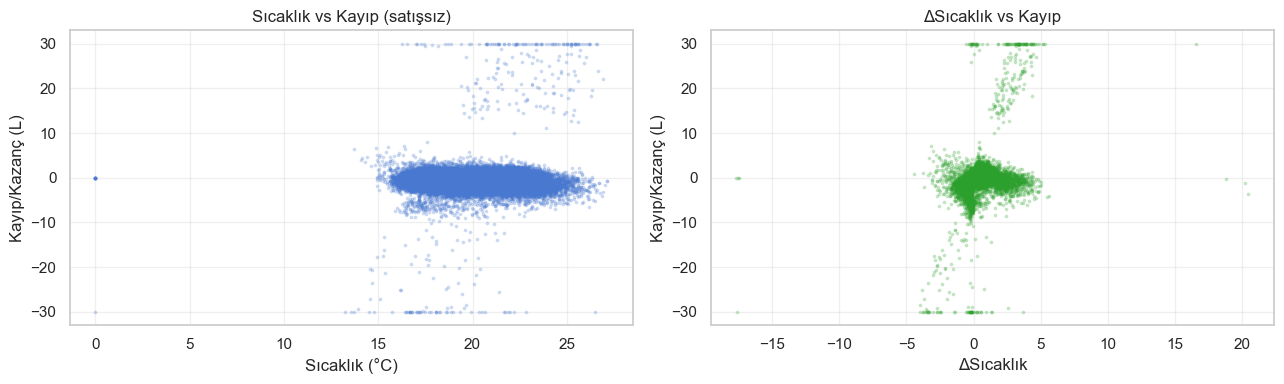

Korelasyon (kayip_kazanc ile):
sicaklik       0.01
dsic           0.09
kayip_kazanc   1.00

=== İstasyon özeti ===


,ort_sicaklik,ort_kayip,satis_toplam
istasyon_kodu,,,
IST_001,20.16,-0.01,"1,392,944.54"
IST_002,20.15,-0.38,"1,411,750.90"
IST_003,20.12,0.24,"783,508.42"
IST_004,20.19,-0.08,"1,340,055.40"
IST_005,20.18,0.55,"801,628.03"
IST_006,20.14,-0.01,"887,830.64"
IST_007,20.19,2.36,"1,182,019.18"
IST_008,20.17,-0.04,"743,249.76"


In [3]:
nosale = ue[(ue.pompa_satis == 0) & ue.sicaklik.notna()].copy()
nosale['dsic'] = nosale.groupby(['istasyon_kodu','tank_no'])['sicaklik'].diff()
sub = nosale.dropna(subset=['dsic'])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(sub['sicaklik'], sub['kayip_kazanc'].clip(-30, 30), s=3, alpha=0.2)
ax[0].set_xlabel('Sıcaklık (°C)'); ax[0].set_ylabel('Kayıp/Kazanç (L)')
ax[0].set_title('Sıcaklık vs Kayıp (satışsız)')
ax[1].scatter(sub['dsic'], sub['kayip_kazanc'].clip(-30, 30), s=3, alpha=0.2, color='tab:green')
ax[1].set_xlabel('ΔSıcaklık'); ax[1].set_ylabel('Kayıp/Kazanç (L)')
ax[1].set_title('ΔSıcaklık vs Kayıp')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='01_sicaklik_kayip')

corr = sub[['sicaklik','dsic','kayip_kazanc']].corr()['kayip_kazanc']
print('Korelasyon (kayip_kazanc ile):')
print(corr.round(3).to_string())

# İstasyon kırılımında ortalama sıcaklık ve kayıp
ist_ozet = ue.groupby('istasyon_kodu').agg(
    ort_sicaklik=('sicaklik','mean'),
    ort_kayip=('kayip_kazanc','mean'),
    satis_toplam=('pompa_satis','sum'),
).round(2)
print('\n=== İstasyon özeti ===')
display(ist_ozet)

## 2. Kümülatif kayıp trendleri

Sürekli aşağı giden kümülatif eğim = kronik kayıp (statik sızıntı adayı).

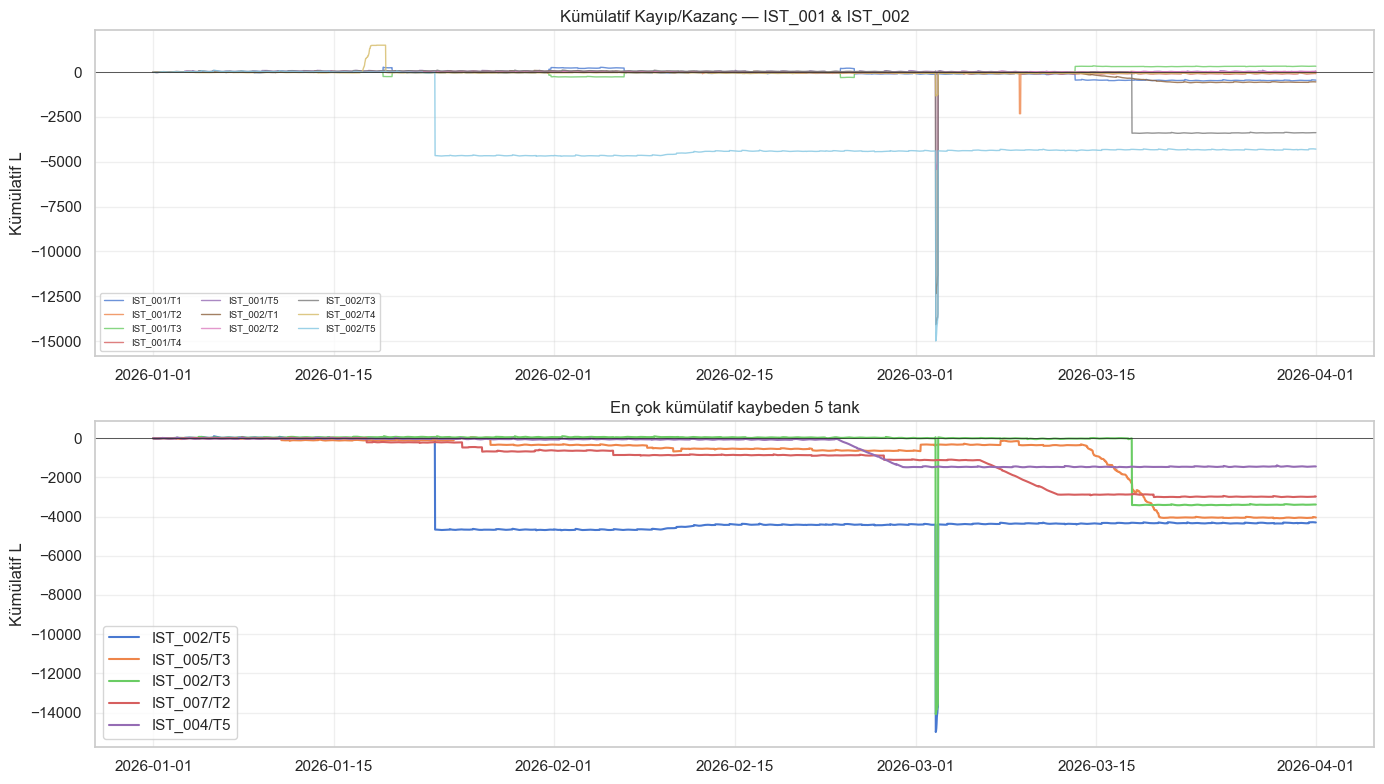

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/02_kumulatif_trend.png')

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# IST_001 ve IST_002 — tüm tanklar
ax = axes[0]
for (st, tk), g in ue.groupby(['istasyon_kodu','tank_no']):
    if st in ('IST_001', 'IST_002'):
        g = g.sort_values('saat_1')
        ax.plot(g['saat_1'], g['kumulatif_kayip_kazanc'], lw=1, label=f'{st}/T{tk}', alpha=0.8)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Kümülatif Kayıp/Kazanç — IST_001 & IST_002')
ax.set_ylabel('Kümülatif L'); ax.legend(fontsize=7, ncol=3)

# En çok kümülatif kaybeden 5 tank
ax = axes[1]
son = ue.sort_values('saat_1').groupby(['istasyon_kodu','tank_no']).last()
top5 = son.nsmallest(5, 'kumulatif_kayip_kazanc')
for (st, tk), _ in top5.iterrows():
    g = ue[(ue.istasyon_kodu==st) & (ue.tank_no==tk)].sort_values('saat_1')
    ax.plot(g['saat_1'], g['kumulatif_kayip_kazanc'], lw=1.5, label=f'{st}/T{tk}')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('En çok kümülatif kaybeden 5 tank')
ax.set_ylabel('Kümülatif L'); ax.legend()
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='02_kumulatif_trend')

## 3. Tanklar arası karşılaştırma

Boxplot + istatistik tablosu — hangi tank daha değişken / daha çok kaybediyor?

=== Tank istatistikleri (tümü) ===


,ort_kayip,std_kayip,min_kum,satis_toplam,satisiz_oran
tank_key,,,,,
IST_002/T5,-0.99,226.32,"-4,297.04","540,500.54",0.18
IST_005/T3,-0.94,12.34,"-4,042.03","287,527.02",0.31
IST_002/T3,-0.78,302.39,"-3,381.65","244,220.23",0.36
IST_007/T2,-0.69,8.53,"-2,971.74","154,459.18",0.36
IST_004/T5,-0.33,3.33,"-1,437.15","275,486.91",0.32
IST_004/T4,-0.31,12.41,"-1,325.66","163,485.26",0.34
IST_003/T1,-0.14,3.38,-595.02,"307,758.08",0.30
IST_002/T1,-0.13,254.35,-549.47,"361,000.57",0.26
IST_001/T1,-0.11,11.62,-453.61,"405,989.93",0.23


,ort_kayip,std_kayip,min_kum,satis_toplam,satisiz_oran
tank_key,,,,,
IST_002/T2,0.01,112.45,45.17,"156,013.71",0.35
IST_001/T5,0.01,4.43,42.72,"492,544.36",0.19
IST_004/T3,0.02,3.68,75.08,"390,107.54",0.24
IST_001/T3,0.07,11.23,322.72,"133,750.80",0.52
IST_007/T4,0.20,98.17,860.70,"159,246.07",0.35
IST_004/T2,0.30,12.38,"1,274.98","154,420.62",0.36
IST_005/T2,0.82,5.78,"3,520.13","96,407.12",0.49
IST_003/T2,0.88,83.78,"3,787.73","305,936.92",0.21
IST_005/T1,1.76,119.46,"7,612.01","417,693.89",0.23


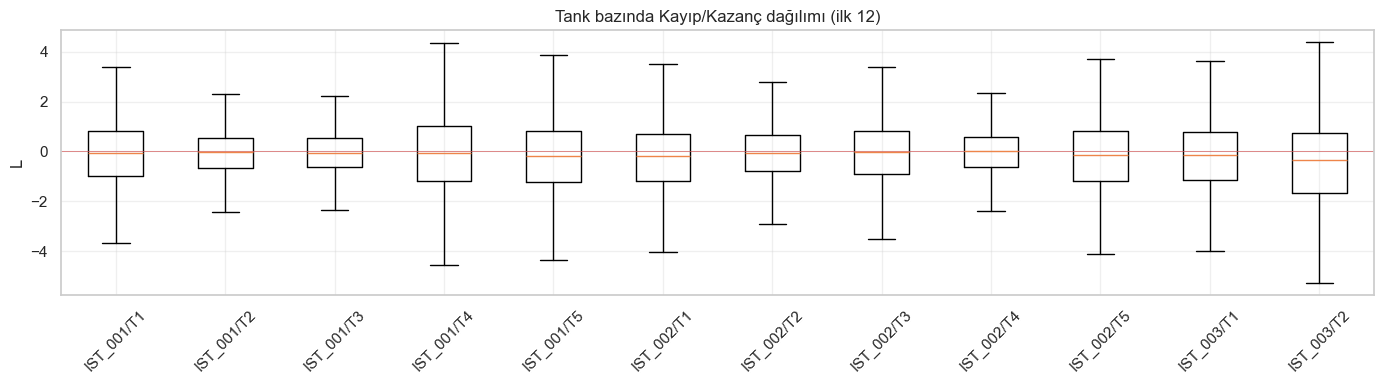

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/03_tank_boxplot.png')

In [5]:
ue['tank_key'] = ue['istasyon_kodu'] + '/T' + ue['tank_no'].astype(str)

tank_stats = ue.groupby('tank_key').agg(
    ort_kayip=('kayip_kazanc','mean'),
    std_kayip=('kayip_kazanc','std'),
    min_kum=('kumulatif_kayip_kazanc','last'),
    satis_toplam=('pompa_satis','sum'),
    satisiz_oran=('pompa_satis', lambda x: (x==0).mean()),
).round(2)
print('=== Tank istatistikleri (tümü) ===')
display(tank_stats.sort_values('ort_kayip').head(10))
display(tank_stats.sort_values('ort_kayip').tail(10))

keys = ue['tank_key'].unique()[:12]
data = [ue[ue.tank_key==k]['kayip_kazanc'].clip(-40, 40).values for k in keys]
fig, ax = plt.subplots(figsize=(14, 4))
ax.boxplot(data, tick_labels=keys, showfliers=False)
ax.axhline(0, color='r', lw=0.5)
ax.set_title('Tank bazında Kayıp/Kazanç dağılımı (ilk 12)')
ax.set_ylabel('L'); plt.xticks(rotation=45)
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='03_tank_boxplot')

## 4. Manifold çifti analizi

Manifold bağlı tanklarda ters yönlü kayıp/kazanç beklenir (check-valve kaçırması).

Manifold tanklar:


,istasyon_kodu,tank_no,manifold_grup_no,akaryakit_turu
0,IST_001,1,1,Motorin(Excellium)
2,IST_001,3,1,Motorin(Excellium)
14,IST_004,2,1,KB 95 Oktan Excellium
16,IST_004,4,1,KB 95 Oktan Excellium
18,IST_005,1,1,Motorin(Excellium)
20,IST_005,3,1,Motorin(Excellium)
26,IST_007,2,1,KB 95 Oktan Excellium
28,IST_007,4,1,KB 95 Oktan Excellium



=== Manifold çift korelasyonları ===


,istasyon,grup,tank_a,tank_b,kk_korelasyon,n_donem
0,IST_001,1,1,3,-0.94,4320
1,IST_004,1,2,4,-0.96,4320
2,IST_005,1,1,3,-0.07,4318
3,IST_007,1,2,4,-0.07,4310


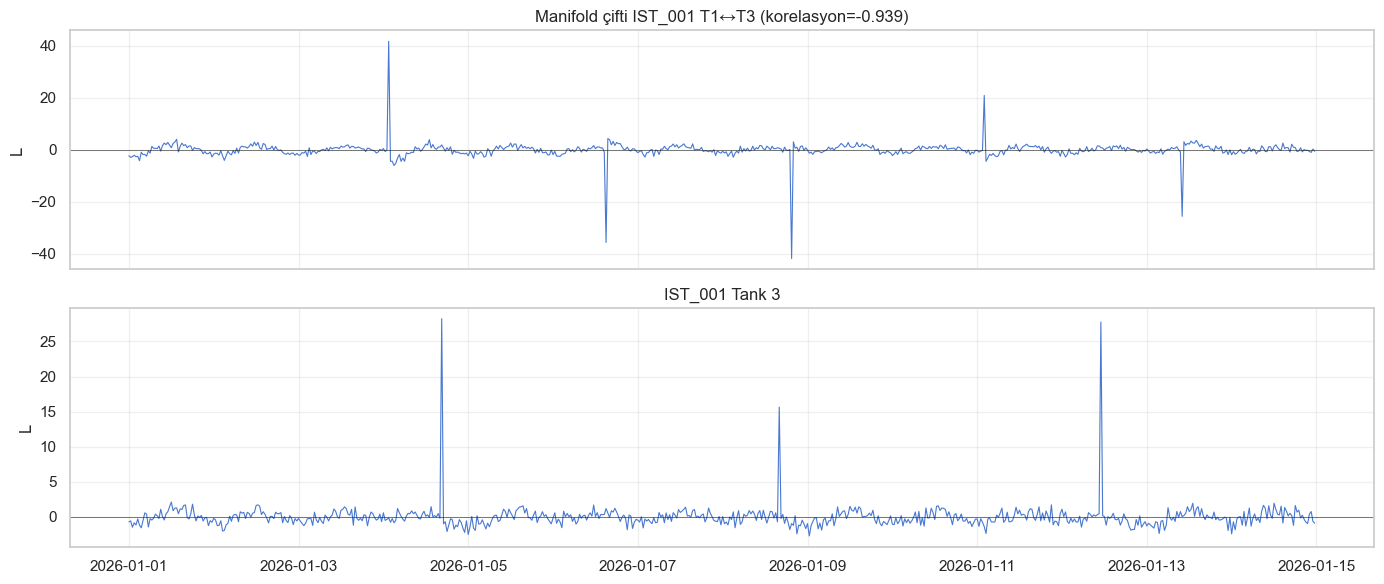

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/04_manifold_cift.png')

In [6]:
man = tanks[tanks.is_manifold == 1][['istasyon_kodu','tank_no','manifold_grup_no','akaryakit_turu']]
print('Manifold tanklar:')
display(man)

# Tüm çiftler için korelasyon tablosu
pairs = []
for (ist, mg), g in man.groupby(['istasyon_kodu','manifold_grup_no']):
    tn = sorted(g['tank_no'].tolist())
    if len(tn) == 2:
        a, b = tn
        ua = ue[(ue.istasyon_kodu==ist)&(ue.tank_no==a)].set_index('saat_1')['kayip_kazanc']
        ub = ue[(ue.istasyon_kodu==ist)&(ue.tank_no==b)].set_index('saat_1')['kayip_kazanc']
        m = pd.concat([ua, ub], axis=1, keys=['a','b']).dropna()
        corr = m['a'].corr(m['b']) if len(m) > 50 else np.nan
        pairs.append({'istasyon': ist, 'grup': mg, 'tank_a': a, 'tank_b': b,
                      'kk_korelasyon': round(corr, 3), 'n_donem': len(m)})
pair_df = pd.DataFrame(pairs)
print('\n=== Manifold çift korelasyonları ===')
display(pair_df)

# İlk çift — zaman serisi
st, mg = pair_df.iloc[0]['istasyon'], pair_df.iloc[0]['grup']
ta, tb = int(pair_df.iloc[0]['tank_a']), int(pair_df.iloc[0]['tank_b'])
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for tk, ax in zip([ta, tb], axes):
    g = ue[(ue.istasyon_kodu==st)&(ue.tank_no==tk)].sort_values('saat_1').iloc[:48*14]
    ax.plot(g['saat_1'], g['kayip_kazanc'], lw=0.8)
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel('L'); ax.set_title(f'{st} Tank {tk}')
axes[0].set_title(f'Manifold çifti {st} T{ta}↔T{tb} (korelasyon={pair_df.iloc[0]["kk_korelasyon"]})')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='04_manifold_cift')

## 5. Null / eksik veri kümelenmesi

Null'lar rastgele değil — probe arızası, router gecikmesi, mapping hatası senaryoları.

In [7]:
# Null matrisi — tüm tablolar
null_rows = []
for name, df in dfs.items():
    for col in df.columns:
        n = df[col].isna().sum()
        if n:
            null_rows.append({'tablo': name, 'kolon': col, 'null': n,
                              'oran_pct': round(100*n/len(df), 2)})
null_df = pd.DataFrame(null_rows).sort_values('null', ascending=False)
print('=== Null özeti (tüm tablolar) ===')
display(null_df.head(15))

# Sıcaklık null — tank × gün kümesi
tmp = ue.copy()
tmp['gun'] = tmp['saat_1'].dt.date
tmp['sic_null'] = tmp['sicaklik'].isna()
sic_pivot = tmp.groupby(['istasyon_kodu','tank_no'])['sic_null'].sum()
print('\nSıcaklık NaN (tank, >0):')
print(sic_pivot[sic_pivot > 0].to_string())

# Merkeze geliş gecikmesi
inv2 = inv.dropna(subset=['merkeze_gelis_tarihi']).copy()
inv2['gecikme_dk'] = (inv2['merkeze_gelis_tarihi'] - inv2['envanter_tarihi']).dt.total_seconds() / 60
print('\nGecikme istatistikleri (dk):')
print(inv2['gecikme_dk'].describe().round(1).to_string())

=== Null özeti (tüm tablolar) ===


,tablo,kolon,null,oran_pct
1,transactions,tank_no,2548,1.10
3,transactions,birim_fiyat,927,0.40
2,transactions,litre,463,0.20
13,ue1t_30min,baslangic_seviyesi_cm,414,0.30
11,inventory_30min,merkeze_gelis_tarihi,276,0.20
7,inventory_30min,urun_miktari_net,240,0.17
10,inventory_30min,sicaklik,240,0.17
12,ue1t_30min,sicaklik,240,0.17
6,deliveries,merkeze_gelis_tarihi,170,15.33
5,deliveries,sicaklik,109,9.83



Sıcaklık NaN (tank, >0):
istasyon_kodu  tank_no
IST_002        1          48
               4          48
IST_003        1          48
               3          48
IST_008        2          48

Gecikme istatistikleri (dk):
count   137,918.00
mean          7.10
std          35.20
min           1.00
25%           4.00
50%           6.00
75%           8.00
max       1,795.80


## 6. Günlük ↔ 30 dk rollup

`daily.fark` ile UE1T 30 dk kayıp/kazanç toplamının aynı günde tutarlı olup olmadığı.

=== Günlük fark vs UE1T kk toplam ===
           fark  ue1t_kk_toplam  fark_ue1t_fark
count  2,880.00        2,880.00        2,880.00
mean      13.89           13.89            0.00
std      849.34          849.34            0.00
min   -4,623.45       -4,623.45           -0.00
25%       -8.23           -8.23           -0.00
50%       -0.58           -0.58            0.00
75%        7.35            7.35            0.00
max   43,121.62       43,121.62            0.00

Max |fark - ue1t_kk|: 0.00 L

Ort. fark — alarm vs normal:
       count   mean      std
alarm                       
0       2709  -0.35    12.63
1        171 239.40 3,487.08


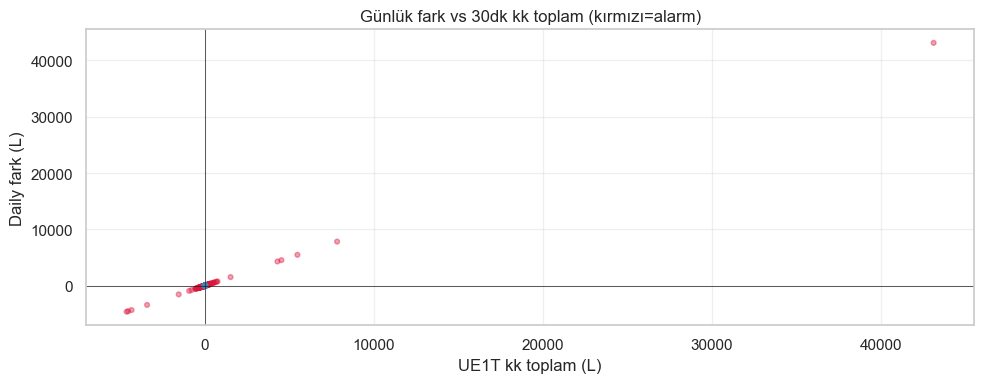

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/06_daily_ue1t_rollup.png')

In [8]:
ue['tarih'] = ue['saat_1'].dt.normalize()
ue_gun = ue.groupby(['istasyon_kodu','tank_no','tarih'], as_index=False).agg(
    ue1t_kk_toplam=('kayip_kazanc','sum'),
    ue1t_satis=('pompa_satis','sum'),
    ue1t_dolum=('tanka_dolum','sum'),
)
m = daily.merge(ue_gun, on=['istasyon_kodu','tank_no','tarih'], how='left')
m['fark_ue1t_fark'] = m['fark'] - m['ue1t_kk_toplam']

print('=== Günlük fark vs UE1T kk toplam ===')
print(m[['fark','ue1t_kk_toplam','fark_ue1t_fark']].describe().round(2).to_string())
print(f'\nMax |fark - ue1t_kk|: {m["fark_ue1t_fark"].abs().max():.2f} L')

# Alarm günleri vs normal
print('\nOrt. fark — alarm vs normal:')
print(m.groupby('alarm')['fark'].agg(['count','mean','std']).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = m['alarm'].map({0:'steelblue', 1:'crimson'})
ax.scatter(m['ue1t_kk_toplam'], m['fark'], c=colors, alpha=0.4, s=12)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('UE1T kk toplam (L)'); ax.set_ylabel('Daily fark (L)')
ax.set_title('Günlük fark vs 30dk kk toplam (kırmızı=alarm)')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='06_daily_ue1t_rollup')

## 7. Saat × haftanın günü heatmap

Kayıp/kazancın hangi saat ve günde yoğunlaştığını görürüz (manipülasyon / gece deseni).

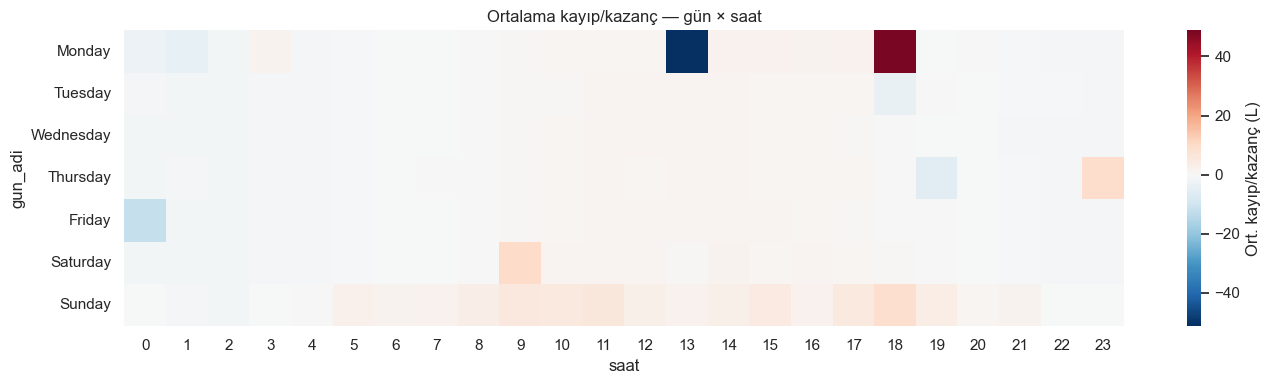


Gece vs gündüz kayıp/kazanç:
       count  mean    std
gece                     
0     103640  0.82 105.31
1      34554 -1.29  41.72


In [9]:
ue['saat'] = ue['saat_1'].dt.hour
ue['haftanin_gunu'] = ue['saat_1'].dt.dayofweek
ue['gun_adi'] = ue['saat_1'].dt.day_name()

heat = ue.pivot_table(
    index='gun_adi', columns='saat', values='kayip_kazanc', aggfunc='mean'
)
gun_sira = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat = heat.reindex([g for g in gun_sira if g in heat.index])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heat, cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Ort. kayıp/kazanç (L)'})
ax.set_title('Ortalama kayıp/kazanç — gün × saat')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='07_heatmap_gun_saat')

# Gece vs gündüz özet
ue['gece'] = ue['saat'].between(0, 5).astype(int)
print('\nGece vs gündüz kayıp/kazanç:')
print(ue.groupby('gece')['kayip_kazanc'].agg(['count','mean','std']).round(2).to_string())

## 8. Dolum sonrası kayıp/kazanç

Dolum olaylarından sonraki 6 saatlik pencerede anormal kayıp var mı? (hayali/algılanmayan dolum).

Dolum eşleşen UE1T dönem: 1,109

Dolum anı kayıp/kazanç istatistikleri:
count    1,109.00
mean        16.60
std        268.48
min     -4,649.26
25%        -12.44
50%         23.17
75%         33.66
max      4,531.92

=== En büyük 5 dolum ===


,dolum_baslangic,istasyon_kodu,tank_no,dolum_net,dolum_oncesi_hacim,dolum_sonrasi_hacim
634,2026-01-02 18:36:00,IST_005,3,"12,994.52","5,503.85","18,498.37"
890,2026-01-20 17:03:00,IST_007,1,"12,981.96",NaN,"18,556.15"
686,2026-02-16 15:37:00,IST_005,1,"12,979.52","5,525.83","18,505.35"
54,2026-01-28 10:41:00,IST_001,5,"12,972.47","7,531.81","20,504.28"
940,2026-02-18 19:08:00,IST_007,1,"12,966.21",NaN,"18,396.83"


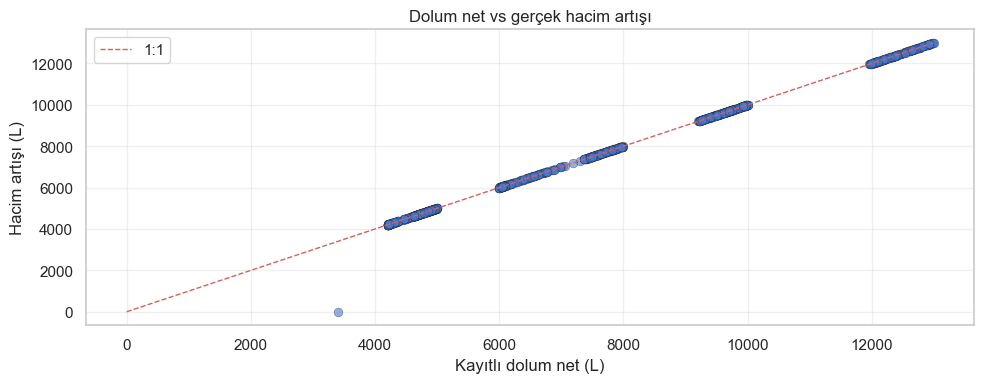

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/08_dolum_analizi.png')

In [10]:
# Dolum zamanlarını UE1T ile eşleştir
deliv2 = deliv.copy()
deliv2['dolum_saat'] = deliv2['dolum_baslangic'].dt.floor('30min')

dolum_donem = ue.merge(
    deliv2[['istasyon_kodu','tank_no','dolum_saat','dolum_net']],
    left_on=['istasyon_kodu','tank_no','saat_1'],
    right_on=['istasyon_kodu','tank_no','dolum_saat'],
    how='inner',
)
print(f'Dolum eşleşen UE1T dönem: {len(dolum_donem):,}')
print('\nDolum anı kayıp/kazanç istatistikleri:')
print(dolum_donem['kayip_kazanc'].describe().round(2).to_string())

# En büyük 5 dolum
top_dolum = deliv.nlargest(5, 'dolum_net')
print('\n=== En büyük 5 dolum ===')
display(top_dolum[['dolum_baslangic','istasyon_kodu','tank_no','dolum_net','dolum_oncesi_hacim','dolum_sonrasi_hacim']])

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(deliv['dolum_net'], deliv['dolum_sonrasi_hacim'] - deliv['dolum_oncesi_hacim'],
           alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
ax.plot([0, deliv['dolum_net'].max()], [0, deliv['dolum_net'].max()], 'r--', lw=1, label='1:1')
ax.set_xlabel('Kayıtlı dolum net (L)'); ax.set_ylabel('Hacim artışı (L)')
ax.set_title('Dolum net vs gerçek hacim artışı')
ax.legend(); plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='08_dolum_analizi')

## 9. Envanter katmanı — su ve brüt/net

UE1T + envanter join ile su sıçraması ve sıcaklık kompanzasyonu.

IST_001 T1 join satır: 4,320

Brüt-net fark: count   4,320.00
mean       40.40
std        21.60
min         0.13
25%        24.33
50%        37.12
75%        51.61
max       152.02

Su sıçrama (>0.05 cm): 0


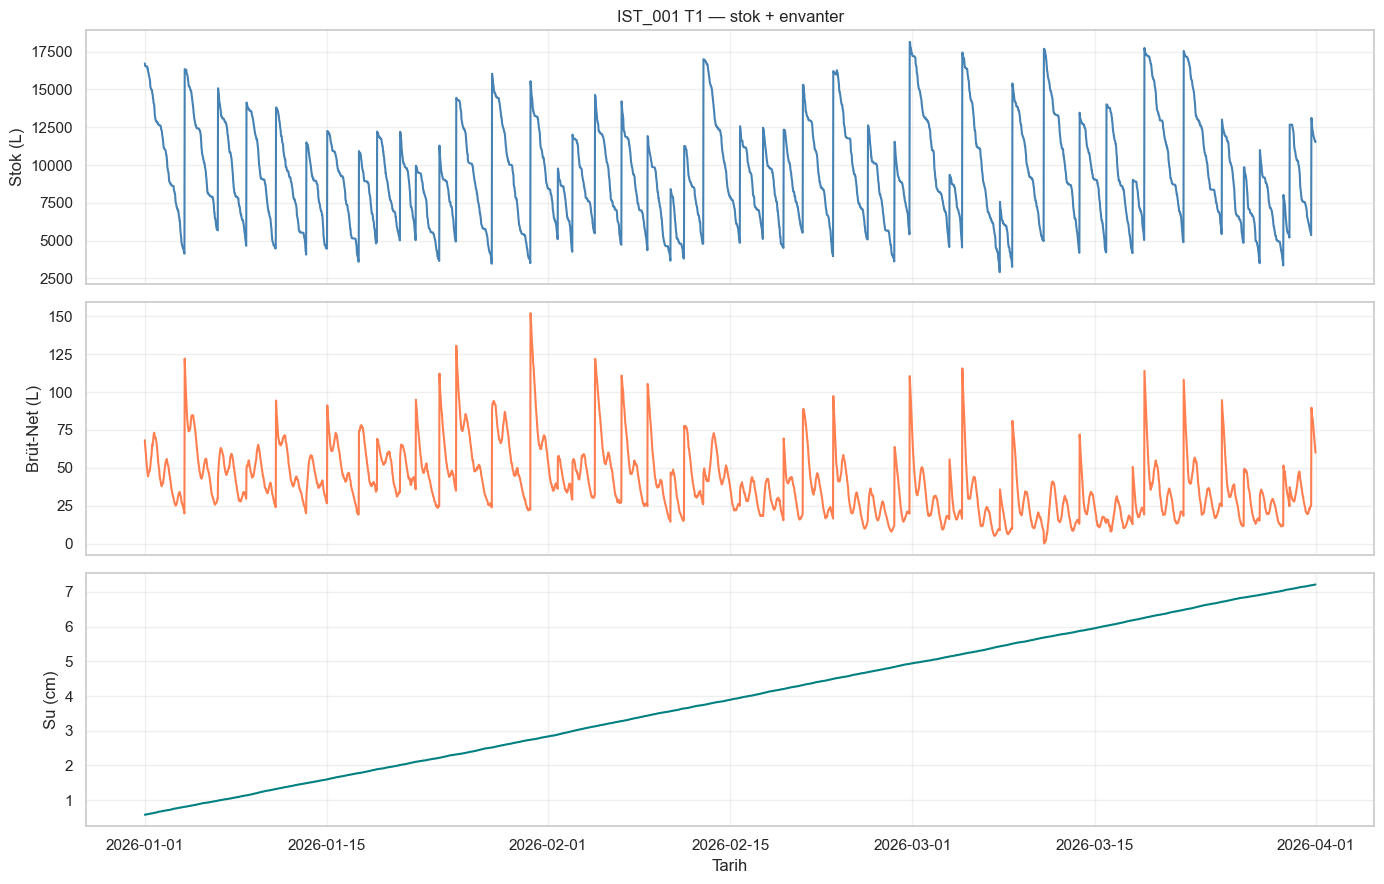

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/09_envanter_join.png')

In [11]:
IST, TANK = 'IST_001', 1
merged = merge_ue1t_inventory(
    filter_tank(ue, IST, TANK),
    filter_tank(inv, IST, TANK),
)
merged = merged.sort_values('saat_1')
merged['brut_net_fark'] = merged['urun_miktari_brut'] - merged['urun_miktari_net']
merged['su_diff'] = merged.groupby(['istasyon_kodu','tank_no'])['su_seviyesi_cm'].diff()

print(f'{IST} T{TANK} join satır: {len(merged):,}')
print('\nBrüt-net fark:', merged['brut_net_fark'].describe().round(2).to_string())
print('\nSu sıçrama (>0.05 cm):', (merged['su_diff'] > 0.05).sum())

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(merged['saat_1'], merged['donem_sonu_stok'], color='steelblue')
axes[0].set_ylabel('Stok (L)'); axes[0].set_title(f'{IST} T{TANK} — stok + envanter')
axes[1].plot(merged['saat_1'], merged['brut_net_fark'], color='coral')
axes[1].set_ylabel('Brüt-Net (L)')
axes[2].plot(merged['saat_1'], merged['su_seviyesi_cm'].fillna(0), color='teal')
axes[2].set_ylabel('Su (cm)'); axes[2].set_xlabel('Tarih')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='09_envanter_join')

## 10. Unmapped satış analizi

`tank_no` null satışlar — mapping hatası; katman tutarlılığını etkiler.

In [12]:
unmapped = tx[tx['tank_no'].isna()]
mapped   = tx[tx['tank_no'].notna()]
print(f'Unmapped işlem : {len(unmapped):,} ({100*len(unmapped)/len(tx):.2f}%)')
print(f'Unmapped litre : {unmapped["litre"].sum():,.1f} L')
print(f'Mapped litre   : {mapped["litre"].sum():,.1f} L')

print('\n=== Unmapped — istasyon kırılımı ===')
display(unmapped.groupby('istasyon_kodu').agg(
    islem=('litre','count'), litre=('litre','sum')
).sort_values('litre', ascending=False))

# TX vs UE1T fark özeti
checks = run_all_checks(dfs)
txu = checks['tx_to_ue1t']
print('\n=== TX↔UE1T fark özeti ===')
print(f'Uyuşmayan dönem: {(txu["tx_ue1t_fark"].abs() > 0.01).sum():,}')
print(txu['tx_ue1t_fark'].describe().round(2).to_string())

Unmapped işlem : 2,548 (1.10%)
Unmapped litre : 93,008.1 L
Mapped litre   : 8,433,509.4 L

=== Unmapped — istasyon kırılımı ===


,islem,litre
istasyon_kodu,,
IST_004,418,"15,477.97"
IST_001,381,"13,969.06"
IST_002,369,"13,875.41"
IST_007,337,"12,618.15"
IST_006,330,"10,956.76"
IST_008,223,"8,891.62"
IST_003,265,"8,758.46"
IST_005,222,"8,460.64"



=== TX↔UE1T fark özeti ===
Uyuşmayan dönem: 2,941
count   138,194.00
mean          0.79
std           6.65
min          -0.00
25%           0.00
50%           0.00
75%           0.00
max         214.01


## 11. Alarm günü 30 dk profili

SEL alarmı olan günlerde 30 dk kayıp/kazanç nasıl dağılıyor?

Alarm gün-tank: 171  (oran: 5.9%)

=== En yüksek |fark| alarm günleri ===


,tarih,istasyon_kodu,tank_no,fark,satis,sel,alarm
2316,2026-03-08,IST_007,1,"43,121.62","47,893.20",263.47,1
1636,2026-01-17,IST_005,1,"7,830.29","4,867.86",48.34,1
1056,2026-03-08,IST_003,2,"5,481.74","3,530.53",41.65,1


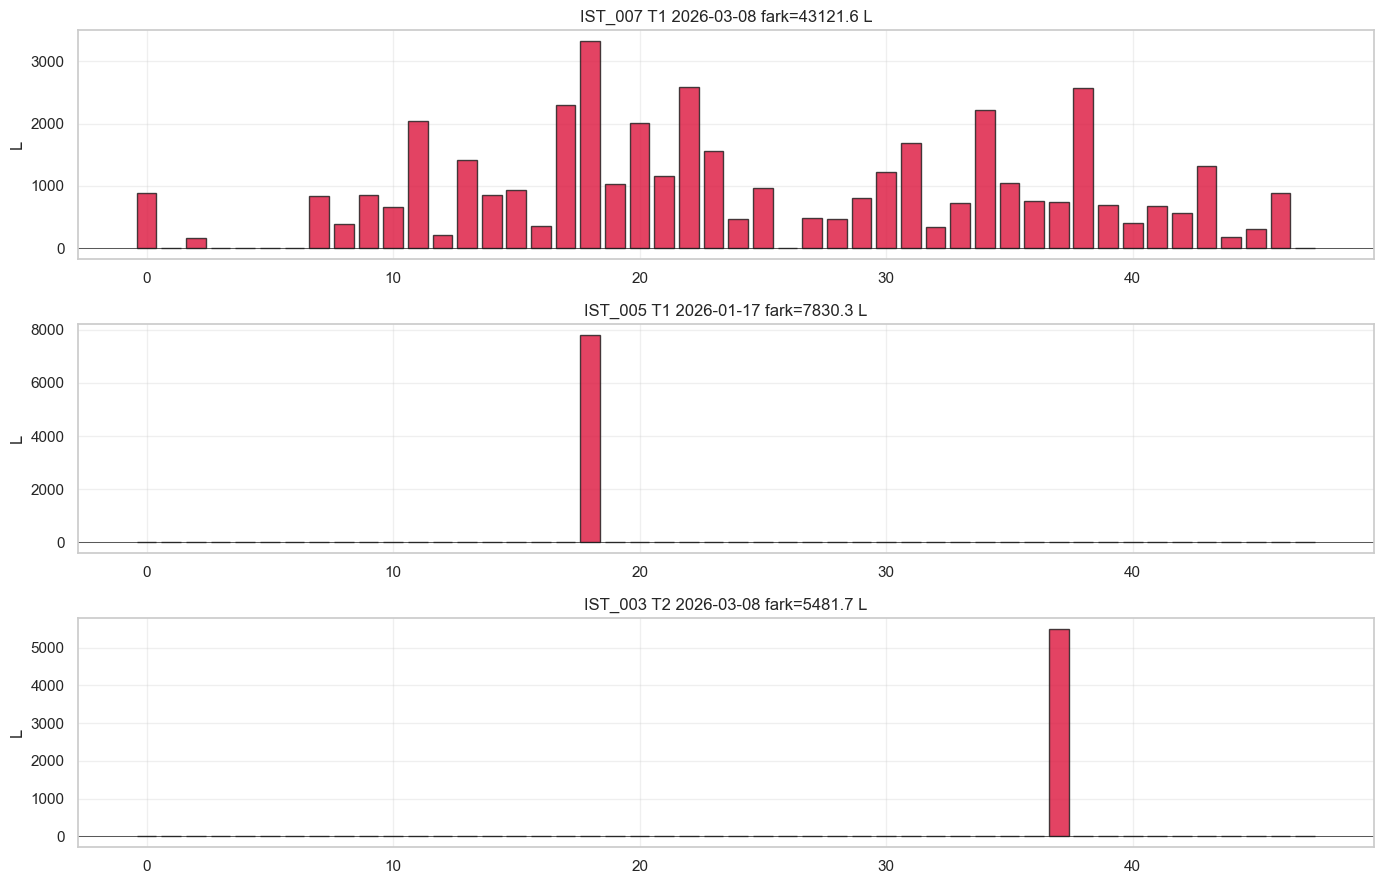

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/11_alarm_gun_profil.png')

In [13]:
alarm_gunler = daily[daily['alarm'] == 1].copy()
print(f'Alarm gün-tank: {len(alarm_gunler):,}  (oran: {daily["alarm"].mean():.1%})')

# En yüksek |fark| 3 alarm günü
top_alarm = alarm_gunler.assign(fark_abs=alarm_gunler['fark'].abs()).nlargest(3, 'fark_abs')
print('\n=== En yüksek |fark| alarm günleri ===')
display(top_alarm[['tarih','istasyon_kodu','tank_no','fark','satis','sel','alarm']])

fig, axes = plt.subplots(len(top_alarm), 1, figsize=(14, 3*len(top_alarm)), sharex=False)
if len(top_alarm) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, top_alarm.iterrows()):
    u = ue[(ue.istasyon_kodu==row.istasyon_kodu) & (ue.tank_no==row.tank_no)
           & (ue['tarih']==row.tarih)]
    ax.bar(range(len(u)), u['kayip_kazanc'], color='crimson', edgecolor='k', alpha=0.8)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('L')
    ax.set_title(f'{row.istasyon_kodu} T{row.tank_no} {row.tarih.date()} fark={row.fark:.1f} L')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='11_alarm_gun_profil')

## 12. Tank risk özeti tablosu

Her tank için birleşik metrikler — FE ve ML öncesi önceliklendirme.

In [14]:
# Tank meta + UE1T + daily rollup
ue2 = ue.copy()
ue2['satisiz_kayip_flag'] = ((ue2['pompa_satis'] == 0) & (ue2['kayip_kazanc'] < -5)).astype(int)

tank_risk = ue2.groupby(['istasyon_kodu','tank_no']).agg(
    ort_kayip=('kayip_kazanc','mean'),
    std_kayip=('kayip_kazanc','std'),
    satisiz_kayip=('satisiz_kayip_flag','sum'),
    kum_son=('kumulatif_kayip_kazanc','last'),
    sic_null=('sicaklik', lambda x: x.isna().sum()),
).reset_index()

alarm_cnt = daily.groupby(['istasyon_kodu','tank_no'])['alarm'].sum().reset_index(name='alarm_gun')
tank_risk = tank_risk.merge(alarm_cnt, on=['istasyon_kodu','tank_no'], how='left')
tank_risk = tank_risk.merge(
    tanks[['istasyon_kodu','tank_no','kapasite','akaryakit_turu','is_manifold','bolmeli']],
    on=['istasyon_kodu','tank_no'], how='left',
)
tank_risk['tank_key'] = tank_risk['istasyon_kodu'] + '/T' + tank_risk['tank_no'].astype(str)

print('=== Tank risk tablosu (en çok alarm) ===')
display(tank_risk.sort_values('alarm_gun', ascending=False).head(10))

print('\n=== Tank risk tablosu (en çok kümülatif kayıp) ===')
display(tank_risk.nsmallest(5, 'kum_son')[['tank_key','ort_kayip','kum_son','alarm_gun','is_manifold','akaryakit_turu']])

# Kaydet
out = ROOT / 'output' / 'tank_risk_ozet.csv'
out.parent.mkdir(parents=True, exist_ok=True)
tank_risk.to_csv(out, index=False)
print(f'\nKaydedildi: {out}')

=== Tank risk tablosu (en çok alarm) ===


,istasyon_kodu,tank_no,ort_kayip,std_kayip,satisiz_kayip,kum_son,sic_null,alarm_gun,kapasite,akaryakit_turu,is_manifold,bolmeli,tank_key
11,IST_003,2,0.88,83.78,34,"3,787.73",0,16,20000,KB 95 Oktan Excellium,0,1,IST_003/T2
20,IST_005,3,-0.94,12.34,36,"-4,042.03",0,15,23000,Motorin(Excellium),1,0,IST_005/T3
18,IST_005,1,1.76,119.46,6,"7,612.01",0,15,23000,Motorin(Excellium),1,0,IST_005/T1
26,IST_007,2,-0.69,8.53,89,"-2,971.74",0,14,10000,KB 95 Oktan Excellium,1,0,IST_007/T2
28,IST_007,4,0.20,98.17,5,860.70,0,10,10000,KB 95 Oktan Excellium,1,0,IST_007/T4
16,IST_004,4,-0.31,12.41,4,"-1,325.66",0,9,10000,KB 95 Oktan Excellium,1,0,IST_004/T4
14,IST_004,2,0.30,12.38,3,"1,274.98",0,9,10000,KB 95 Oktan Excellium,1,0,IST_004/T2
10,IST_003,1,-0.14,3.38,5,-595.02,48,8,23000,Motorin(Excellium),0,0,IST_003/T1
5,IST_002,1,-0.13,254.35,4,-549.47,48,8,23000,Motorin(Excellium),0,0,IST_002/T1
17,IST_004,5,-0.33,3.33,72,"-1,437.15",0,7,20000,Motorin(Excellium),0,0,IST_004/T5



=== Tank risk tablosu (en çok kümülatif kayıp) ===


,tank_key,ort_kayip,kum_son,alarm_gun,is_manifold,akaryakit_turu
9,IST_002/T5,-0.99,"-4,297.04",4,0,Motorin(Excellium)
20,IST_005/T3,-0.94,"-4,042.03",15,1,Motorin(Excellium)
7,IST_002/T3,-0.78,"-3,381.65",3,0,Motorin(Excellium)
26,IST_007/T2,-0.69,"-2,971.74",14,1,KB 95 Oktan Excellium
17,IST_004/T5,-0.33,"-1,437.15",7,0,Motorin(Excellium)



Kaydedildi: /Users/mangtay/Desktop/Staj/eda/output/tank_risk_ozet.csv


## Gün 7 Özeti

| Bölüm | Bulgu |
|-------|-------|
| Veri envanteri | 8 tablo, 90 gün, 32 tank — yıldız şeması tutarlı |
| Sıcaklık | Satışsız dönemde korelasyon zayıf → termal/sızıntı ayrımı mümkün |
| Kümülatif trend | Kronik kaybeden tanklar belirlendi |
| Manifold | Çiftlerde kk korelasyon ≈ -0.94 (ters yön) |
| Null | Sıcaklık null'ları tank-gün kümesi (probe arızası) |
| Daily↔UE1T | Alarm günlerinde fark profili farklı |
| Heatmap | Gece saatlerinde kayıp deseni |
| Dolum | Dolum anı ve hacim artışı karşılaştırması |
| Envanter | Brüt-net fark, su seviyesi join |
| Unmapped TX | ~%1.1 işlem, mapping hatası sinyali |
| Alarm profili | SEL aşım günlerinde 30dk bar grafik |
| Tank risk | `output/tank_risk_ozet.csv` — ML öncesi öncelik listesi |

**Sonraki adım:** Gün 8 Feature Engineering (`feature_engineering/notebooks/GUN08_feature_engineering.ipynb`)
